# Product Innovation Creativity: Four Approaches Compared

This notebook compares four approaches to eliciting creative product innovation responses:

## Tasks (Product Innovation Focus):
1. **Brick Uses**: Generate creative and diverse ways to use a brick
2. **Stapler Improvements**: Enumerate specific enhancements to improve a stapler

## Four Conditions:
1. **BASELINE**: Standard question, no intervention
2. **PROMPTING**: Question + system prompt encouraging creativity
3. **HIGH TEMPERATURE**: Standard question with temperature=1.5 for more randomness/creativity
4. **HIGH STEERING**: Question + Goodfire neural intervention (strength=0.5)

## Evaluation:
- GPT-4 evaluator agent scores each response on creativity (1-10 scale)
- Results plotted for easy comparison

## Goal:
Compare the effectiveness of different creativity elicitation methods.

In [1]:
# Clear cache for fresh responses
import shutil
import os

cache_dir = '.edsl_cache'
if os.path.exists(cache_dir):
    shutil.rmtree(cache_dir)

In [2]:
from edsl import QuestionFreeText, QuestionList, QuestionMultipleChoice, Survey, Agent, AgentList, Model
import os
import pandas as pd
import goodfire
import matplotlib.pyplot as plt
import numpy as np

In [3]:
# Initialize Goodfire
client = goodfire.Client(os.getenv("GOODFIRE_API_KEY"))
base_variant = goodfire.Variant("meta-llama/Llama-3.3-70B-Instruct")

In [4]:
# Product Innovation Creativity Experiment Class
class ProductInnovationExperiment:
    def __init__(self, agents, model, use_creativity_prompt=False):
        self.agents = agents
        self.model = model
        self.questions = []
        self.variant = goodfire.Variant("meta-llama/Llama-3.3-70B-Instruct")
        self.use_creativity_prompt = use_creativity_prompt
        
        # Set system prompt if prompting condition
        if use_creativity_prompt:
            for agent in self.agents:
                agent.traits = {"trait1":"Enabling or empowering creative expression and exploration", "trait2":"Descriptions of creative unconventional thinking, especially 'thinking outside the box'", "trait3":"Professional innovation and creative problem-solving"}


    def setup(self):
        # Two product innovation creativity tasks
        self.questions = [
            # Task 1: Brick uses - divergent thinking on product applications
            QuestionList(
                question_name="detailed_ways_to_use_a_brick",
                question_text="List very detailed ways you can use a brick. Each answer should be a paragraph.",
                max_list_items=10
            ),
            
            # Task 2: Stapler improvements - product enhancement and innovation
            QuestionList(
                question_name="improve_the_stapler_with_many_specific_enhancements",
                question_text="Your goal is to improve the stapler. List as many specific enhancements as you can that would make it better. You may change features, materials, mechanisms, interfaces, or add/remove parts. Do not list new uses; stay focused on improvements to the object itself. For each idea, add enough detail so someone could build or test it.",
                max_list_items=10
            )
        ]

    def run(self, intervention=False, steering_strength=0.5):
        if intervention:
            controller = self.get_creativity_intervention(steering_strength)
            self.model.parameters["controller"] = controller
            self.variant = goodfire.Variant("meta-llama/Llama-3.3-70B-Instruct")
            
            if "interventions" in controller:
                for item in controller["interventions"]:
                    if "features" in item and "features" in item["features"]:
                        for feature_data in item["features"]["features"]:
                            features = client.features.search(feature_data["label"], model=self.variant, top_k=1)
                            if features:
                                self.variant.set(features[0], item["value"])
        else:
            self.model.parameters["controller"] = {}
            self.variant = goodfire.Variant("meta-llama/Llama-3.3-70B-Instruct")

        survey = Survey(self.questions)
        return survey.by(self.agents).by(self.model).run(cache=False)

    def get_creativity_intervention(self, steering_strength=0.5):
        # NOTE: Replace these with actual feature UUIDs from Goodfire feature search
        # steering_strength: 0.2 for low, 0.5 for high
        return {'interventions': [{'mode': 'nudge',
   'features': {'features': [{'uuid': '2c83bf952a3a4213b45f098aa8c015e2',
      'label': 'Enabling or empowering creative expression and exploration',
      'index_in_sae': 13142,
      'max_activation_strength': 1}]},
   'value': steering_strength},
  {'mode': 'nudge',
   'features': {'features': [{'uuid': '96f91d8ed8934998b52bf66a5951dafd',
      'label': "Descriptions of creative unconventional thinking, especially 'thinking outside the box'",
      'index_in_sae': 20117,
      'max_activation_strength': 1}]},
   'value': steering_strength},   {'mode': 'nudge',
   'features': {'features': [{'uuid': 'c148476f6cdc4cd9a2110c24045bfcbe',
      'label': 'Professional innovation and creative problem-solving',
      'index_in_sae': 4992,
      'max_activation_strength': 1}]},
   'value': steering_strength}],

 'scopes': [],
 'name': 'controller__44168204',
 'nonzero_strength_threshold': None,
 'min_nudge_entropy': None,
 'max_nudge_entropy': None}

    def analyze_features(self, results, condition_name, use_base=False, question_name=None):
        """Analyze and return feature activations for a question."""
        variant = base_variant if use_base else self.variant
        
        # If no specific question name, use the first question
        if question_name is None:
            question_name = self.questions[0].question_name
        
        try:
            prompts = results.select(f"prompt.{question_name}_user_prompt").to_list()
            responses = results.select(f"generated_tokens.{question_name}_generated_tokens").to_list()
            
            if prompts and responses:
                prompt = prompts[0]["text"] if isinstance(prompts[0], dict) else prompts[0]
                response = responses[0]
                
                inspector = client.features.inspect(
                    [{"role": "user", "content": str(prompt)}, {"role": "assistant", "content": str(response)}],
                    model=variant
                )
                
                # Return top features as a list of dicts
                return [{"label": act.feature.label, "activation": act.activation} 
                        for act in inspector.top(k=10)]
        except Exception as e:
            return [{"error": str(e)}]
    
    def get_response_data(self, results, question_name):
        """Extract answer and comment for a question."""
        answer = results.select(f"answer.{question_name}").to_list()
        comment = results.select(f"comment.{question_name}_comment").to_list()
        return {
            "answer": answer[0] if answer else "No response",
            "comment": comment[0] if comment else "No comment"
        }

In [5]:
print("="*80)
print("PRODUCT INNOVATION CREATIVITY EXPERIMENT")
print("="*80)
print("\nTasks:")
print("  1. Brick Uses - creative applications")
print("  2. Stapler Improvements - product enhancement")
print("\nConditions:")
print("  1. BASELINE - No intervention")
print("  2. PROMPTING - Creativity-encouraging system prompt")
print("  3. HIGH TEMPERATURE - Temperature=1.5 for randomness")
print("  4. HIGH STEERING - Goodfire neural intervention (strength=0.5)")
print("\nReady to run experiment...")
print("="*80)


PRODUCT INNOVATION CREATIVITY EXPERIMENT

Tasks:
  1. Brick Uses - creative applications
  2. Stapler Improvements - product enhancement

Conditions:
  1. BASELINE - No intervention
  2. PROMPTING - Creativity-encouraging system prompt
  3. HIGH TEMPERATURE - Temperature=1.5 for randomness
  4. HIGH STEERING - Goodfire neural intervention (strength=0.5)

Ready to run experiment...


In [6]:
# Run experiment across all three conditions
timestamp = pd.Timestamp.now().strftime('%Y%m%d_%H%M%S')
results_dir = f"creativity_experiment/product_innovation_{timestamp}"
os.makedirs(results_dir, exist_ok=True)

print("\n" + "="*80)
print("RUNNING EXPERIMENT: FOUR CONDITIONS")
print("="*80)

# Store all results and features
all_results = {}
all_features = {}
all_responses = {}

tasks = ["detailed_ways_to_use_a_brick", "improve_the_stapler_with_many_specific_enhancements"]

# CONDITION 1: BASELINE
print("\n⏳ Running BASELINE (No Intervention)...")
baseline_agents = AgentList([Agent(name="Agent_1", traits={"id": 1})])
baseline_model = Model("meta-llama/Llama-3.3-70B-Instruct", service_name="goodfire")
baseline_exp = ProductInnovationExperiment(baseline_agents, baseline_model, use_creativity_prompt=False)
baseline_exp.setup()
baseline_results = baseline_exp.run(intervention=False)
baseline_results.to_csv(f"{results_dir}/baseline.csv")

all_results['baseline'] = baseline_results
all_features['baseline'] = {}
all_responses['baseline'] = {}

for task in tasks:
    features = baseline_exp.analyze_features(baseline_results, "Baseline", use_base=True, question_name=task)
    all_features['baseline'][task] = features
    
    response = baseline_exp.get_response_data(baseline_results, task)
    all_responses['baseline'][task] = response

print("✓ Baseline complete")

# CONDITION 2: PROMPTING
print("\n⏳ Running PROMPTING (Creativity System Prompt)...")
prompting_agents = AgentList([Agent(name="Agent_1", traits={"id": 1})])
prompting_model = Model("meta-llama/Llama-3.3-70B-Instruct", service_name="goodfire")
prompting_exp = ProductInnovationExperiment(prompting_agents, prompting_model, use_creativity_prompt=True)
prompting_exp.setup()
prompting_results = prompting_exp.run(intervention=False)
prompting_results.to_csv(f"{results_dir}/prompting.csv")

all_results['prompting'] = prompting_results
all_features['prompting'] = {}
all_responses['prompting'] = {}

for task in tasks:
    features = prompting_exp.analyze_features(prompting_results, "Prompting", use_base=True, question_name=task)
    all_features['prompting'][task] = features
    
    response = prompting_exp.get_response_data(prompting_results, task)
    all_responses['prompting'][task] = response

print("✓ Prompting complete")

# CONDITION 3: HIGH TEMPERATURE
print("\n⏳ Running HIGH TEMPERATURE (Temperature=1.5)...")
hightemp_agents = AgentList([Agent(name="Agent_1", traits={"id": 1})])
hightemp_model = Model("meta-llama/Llama-3.3-70B-Instruct", service_name="goodfire", temperature=1.5)
hightemp_exp = ProductInnovationExperiment(hightemp_agents, hightemp_model, use_creativity_prompt=False)
hightemp_exp.setup()
hightemp_results = hightemp_exp.run(intervention=False)
hightemp_results.to_csv(f"{results_dir}/high_temperature.csv")

all_results['high_temperature'] = hightemp_results
all_features['high_temperature'] = {}
all_responses['high_temperature'] = {}

for task in tasks:
    features = hightemp_exp.analyze_features(hightemp_results, "HighTemp", use_base=True, question_name=task)
    all_features['high_temperature'][task] = features
    
    response = hightemp_exp.get_response_data(hightemp_results, task)
    all_responses['high_temperature'][task] = response

print("✓ High Temperature complete")

# CONDITION 4: HIGH STEERING
print("\n⏳ Running HIGH STEERING (Goodfire Neural Intervention, strength=0.5)...")
high_steering_agents = AgentList([Agent(name="Agent_1", traits={"id": 1})])
high_steering_model = Model("meta-llama/Llama-3.3-70B-Instruct", service_name="goodfire")
high_steering_exp = ProductInnovationExperiment(high_steering_agents, high_steering_model, use_creativity_prompt=False)
high_steering_exp.setup()
high_steering_results = high_steering_exp.run(intervention=True, steering_strength=0.5)
high_steering_results.to_csv(f"{results_dir}/high_steering.csv")

all_results['high_steering'] = high_steering_results
all_features['high_steering'] = {}
all_responses['high_steering'] = {}

for task in tasks:
    features = high_steering_exp.analyze_features(high_steering_results, "High Steering", use_base=False, question_name=task)
    all_features['high_steering'][task] = features
    
    response = high_steering_exp.get_response_data(high_steering_results, task)
    all_responses['high_steering'][task] = response

print("✓ High Steering complete")

print("\n" + "="*80)
print("✓ All 4 conditions complete!")
print(f"Results saved to: {results_dir}")
print("="*80)


RUNNING EXPERIMENT: FOUR CONDITIONS

⏳ Running BASELINE (No Intervention)...
✓ Baseline complete

⏳ Running PROMPTING (Creativity System Prompt)...
✓ Prompting complete

⏳ Running HIGH TEMPERATURE (Temperature=1.5)...
✓ High Temperature complete

⏳ Running HIGH STEERING (Goodfire Neural Intervention, strength=0.5)...
✓ High Steering complete

✓ All 4 conditions complete!
Results saved to: creativity_experiment/product_innovation_20251019_143545


In [7]:
# Display results
print("\n\n" + "="*80)
print("RESPONSES FROM ALL CONDITIONS")
print("="*80)

conditions = ['baseline', 'prompting', 'high_temperature', 'high_steering']

for task in tasks:
    print("\n\n" + "█"*80)
    print(f"  TASK: {task.upper().replace('_', ' ')}")
    print("█"*80)
    
    for condition in conditions:
        condition_label = {
            'baseline': 'BASELINE',
            'prompting': 'PROMPTING',
            'high_temperature': 'HIGH TEMPERATURE',
            'high_steering': 'HIGH STEERING'
        }[condition]
        
        print(f"\n{'='*80}")
        print(f"🔷 {condition_label}")
        print("="*80)
        
        # Show response only (no activations for display)
        response_data = all_responses[condition][task]
        print(response_data['answer'])

print("\n\n" + "="*80)



RESPONSES FROM ALL CONDITIONS


████████████████████████████████████████████████████████████████████████████████
  TASK: DETAILED WAYS TO USE A BRICK
████████████████████████████████████████████████████████████████████████████████

🔷 BASELINE
['You can use a brick as a building material by stacking it with other bricks and using mortar to hold them together, creating a strong and durable structure for walls, foundations, and other construction projects.', 'A brick can serve as a bookend, holding up books on a shelf and keeping them organized, while also adding a touch of rustic decor to the room.', 'Bricks can be used as a border or edging material in gardens and landscapes, creating a clear distinction between different areas and adding a pop of color and texture.', 'You can use a brick as a doorstop, propping it against a door to keep it from closing or to hold it open, which can be especially useful in drafty or high-traffic areas.', 'A brick can be repurposed as a paperweight, ho

In [8]:
# Save responses to CSV for evaluation
print("="*80)
print("SAVING RESPONSES FOR EVALUATION")
print("="*80)

# Create simple dataframe with responses only
responses_data = []

for task in tasks:
    for condition in conditions:
        response = all_responses[condition][task]
        
        row = {
            'task': task,
            'condition': condition,
            'response': str(response['answer'])
        }
        
        responses_data.append(row)

# Create DataFrame
responses_df = pd.DataFrame(responses_data)

# Save to CSV
responses_path = f"{results_dir}/responses.csv"
responses_df.to_csv(responses_path, index=False)

print(f"\n✓ Saved responses to: {responses_path}")
print(f"Total: {len(responses_data)} responses (2 tasks × 4 conditions)")
print("="*80)


SAVING RESPONSES FOR EVALUATION

✓ Saved responses to: creativity_experiment/product_innovation_20251019_143545/responses.csv
Total: 8 responses (2 tasks × 4 conditions)


In [9]:
# Save feature activations to files
print("\n" + "="*80)
print("SAVING FEATURE ACTIVATIONS")
print("="*80)

# Save as CSV for easy analysis
activations_data = []

for task in tasks:
    for condition in conditions:
        features = all_features[condition][task]
        
        # Handle both feature lists and error cases
        if features and isinstance(features, list):
            for idx, feature in enumerate(features):
                if 'label' in feature and 'activation' in feature:
                    row = {
                        'task': task,
                        'condition': condition,
                        'rank': idx + 1,  # Feature rank (1-10)
                        'feature_label': feature['label'],
                        'activation': feature['activation']
                    }
                    activations_data.append(row)

# Create DataFrame
activations_df = pd.DataFrame(activations_data)

# Save to CSV
activations_csv_path = f"{results_dir}/activations.csv"
activations_df.to_csv(activations_csv_path, index=False)

print(f"\n✓ Saved activations to: {activations_csv_path}")
print(f"Total: {len(activations_data)} feature activations")

# Also save the raw dictionary as JSON for complete data
import json

activations_json_path = f"{results_dir}/activations.json"
with open(activations_json_path, 'w') as f:
    json.dump(all_features, f, indent=2)

print(f"✓ Saved raw activations to: {activations_json_path}")
print("="*80)



SAVING FEATURE ACTIVATIONS

✓ Saved activations to: creativity_experiment/product_innovation_20251019_143545/activations.csv
Total: 80 feature activations
✓ Saved raw activations to: creativity_experiment/product_innovation_20251019_143545/activations.json


In [10]:
# Evaluate creativity using GPT-5 agent
print("\n" + "="*80)
print("EVALUATING CREATIVITY WITH GPT-5")
print("="*80)

from edsl import QuestionLinearScale

# Create evaluator model (GPT-5)
evaluator_model = Model("gpt-5")

# Store scores
creativity_scores = {}

task_descriptions = {
    "detailed_ways_to_use_a_brick": "List very detailed ways you can use a brick. Each answer should be a paragraph.",
    "improve_the_stapler_with_many_specific_enhancements": "Your goal is to improve the stapler. List as many specific enhancements as you can that would make it better. You may change features, materials, mechanisms, interfaces, or add/remove parts. Do not list new uses; stay focused on improvements to the object itself. For each idea, add enough detail so someone could build or test it."
}

for task in tasks:
    print(f"\n📝 Evaluating {task}...")
    creativity_scores[task] = {}
    
    for condition in conditions:
        response_text = all_responses[condition][task]['answer']
        
        # Create evaluation question
        eval_question = QuestionLinearScale(
            question_name="creativity_score",
            question_text=f"""Rate the creativity of the following task and its response on a scale of 1-10, where:

The task is: {task_descriptions[task]}

Response to evaluate:
{response_text}



Rate the creativity (you can be generous):""",
            question_options=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
            option_labels={1: "Not creative (generic, obvious, conventional ideas)", 10: "Very creative (highly original, novel, unconventional, diverse ideas)"}
        )
        
        # Create evaluator agent
        evaluator = Agent(name="Creativity_Evaluator")
        
        # Run evaluation
        eval_survey = Survey([eval_question])
        eval_results = eval_survey.by(evaluator).by(evaluator_model).run()
        
        # Get score
        score = eval_results.select("creativity_score").to_list()[0]
        creativity_scores[task][condition] = score
        
        print(f"  {condition:20s}: {score}/10")

print("\n" + "="*80)
print("✓ Evaluation complete!")
print("="*80)


EVALUATING CREATIVITY WITH GPT-5

📝 Evaluating detailed_ways_to_use_a_brick...
  baseline            : 3/10
  prompting           : 4/10
  high_temperature    : 1/10
  high_steering       : 3/10

📝 Evaluating improve_the_stapler_with_many_specific_enhancements...
  baseline            : 3/10
  prompting           : 4/10
  high_temperature    : 4/10
  high_steering       : 5/10

✓ Evaluation complete!



PLOTTING RESULTS

✓ Saved plot to: creativity_experiment/product_innovation_20251019_143545/creativity_scores_detailed_ways_to_use_a_brick.png


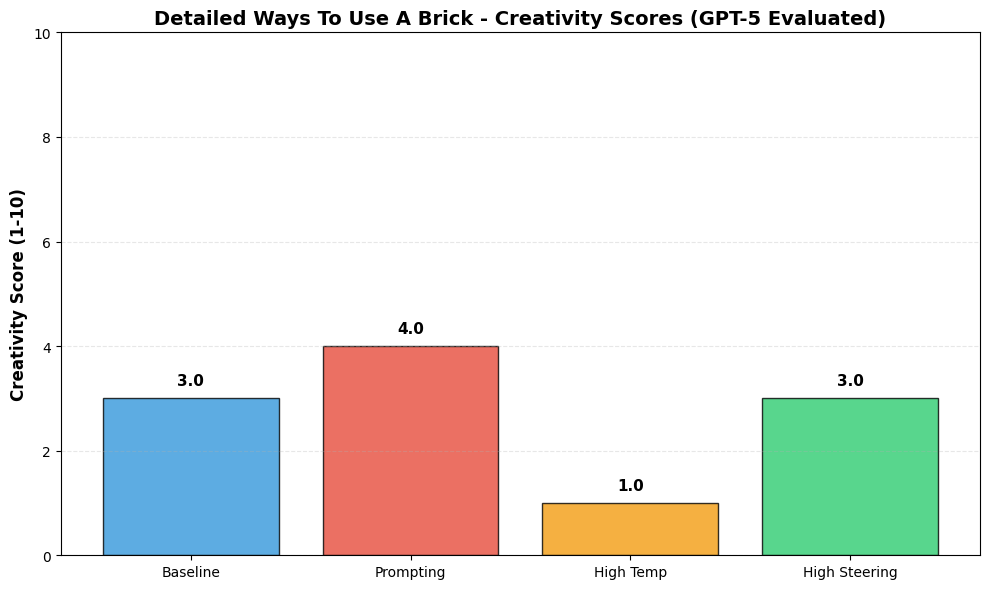


✓ Saved plot to: creativity_experiment/product_innovation_20251019_143545/creativity_scores_improve_the_stapler_with_many_specific_enhancements.png


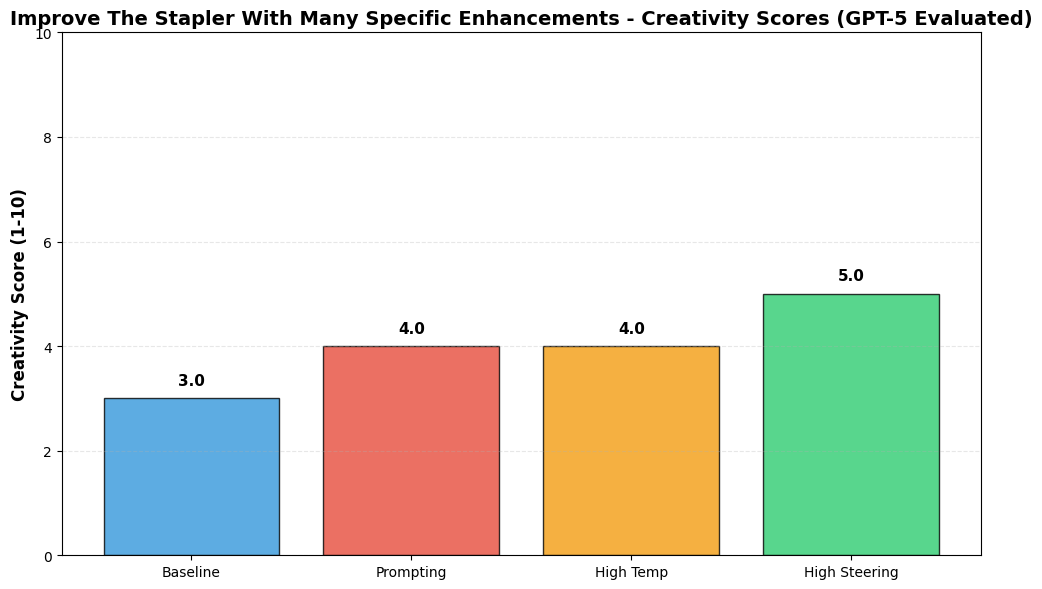


SUMMARY STATISTICS

Detailed Ways To Use A Brick:
  Baseline       : 3.0/10
  Prompting      : 4.0/10
  High Temp      : 1.0/10
  High Steering  : 3.0/10
  → Best: Prompting (4.0)

Improve The Stapler With Many Specific Enhancements:
  Baseline       : 3.0/10
  Prompting      : 4.0/10
  High Temp      : 4.0/10
  High Steering  : 5.0/10
  → Best: High Steering (5.0)

Overall Averages Across Both Tasks:
  Baseline       : 3.00/10
  Prompting      : 4.00/10
  High Temp      : 2.50/10
  High Steering  : 4.00/10

✓ ANALYSIS COMPLETE!


In [11]:
# Plot creativity scores
print("\n" + "="*80)
print("PLOTTING RESULTS")
print("="*80)

# Prepare data for plotting
condition_labels = ['Baseline', 'Prompting', 'High Temp', 'High Steering']
condition_keys = ['baseline', 'prompting', 'high_temperature', 'high_steering']

# Create separate plots for each task
for task in tasks:
    # Create new figure for each task
    fig, ax = plt.subplots(1, 1, figsize=(10, 6))
    
    # Get scores for this task
    scores = [creativity_scores[task][cond] for cond in condition_keys]
    
    # Create bar plot
    bars = ax.bar(condition_labels, scores, color=['#3498db', '#e74c3c', '#f39c12', '#2ecc71'], alpha=0.8, edgecolor='black')
    
    # Customize plot
    ax.set_ylabel('Creativity Score (1-10)', fontsize=12, fontweight='bold')
    ax.set_title(f'{task.replace("_", " ").title()} - Creativity Scores (GPT-5 Evaluated)', 
                 fontsize=14, fontweight='bold')
    ax.set_ylim(0, 10)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    
    # Add value labels on bars
    for bar, score in zip(bars, scores):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.2,
                f'{score:.1f}',
                ha='center', va='bottom', fontweight='bold', fontsize=11)
    
    plt.tight_layout()
    
    # Save plot
    plot_path = f"{results_dir}/creativity_scores_{task}.png"
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    print(f"\n✓ Saved plot to: {plot_path}")
    
    plt.show()

# Print summary statistics
print("\n" + "="*80)
print("SUMMARY STATISTICS")
print("="*80)

for task in tasks:
    print(f"\n{task.replace('_', ' ').title()}:")
    scores = [creativity_scores[task][cond] for cond in condition_keys]
    for label, score in zip(condition_labels, scores):
        print(f"  {label:15s}: {score:.1f}/10")
    
    best_idx = scores.index(max(scores))
    print(f"  → Best: {condition_labels[best_idx]} ({max(scores):.1f})")

# Overall average
print(f"\n{'='*80}")
print("Overall Averages Across Both Tasks:")
print("="*80)
for i, (label, key) in enumerate(zip(condition_labels, condition_keys)):
    avg_score = np.mean([creativity_scores[task][key] for task in tasks])
    print(f"  {label:15s}: {avg_score:.2f}/10")

print("\n" + "="*80)
print("✓ ANALYSIS COMPLETE!")
print("="*80)
